# Combo C: Multi-node + Pure Soft Crossing Reward + GNN+CNN Hybrid + Curriculum + Multi-stage LR# Graph Layout Optimization using Reinforcement Learning with PPO

In [1]:
import os
import sys
import time
import json
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Type

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.7.0
Device: cpu


In [2]:
# ============================================================
# CONFIGURATION — Combo C Settings (v3-FAST)
# ============================================================
ROME_DIR = "/Users/mao/Downloads/Project_RL/rome"  # <-- your rome dataset path
SAVE_PATH = "ppo_combo_c"
OUTPUT_DIR = "./results_combo_cv3"

MAX_NODES = 100
MAX_EDGES = 200
TIMESTEPS_PHASE1 = 30000    # v3-fast: reduced from 50K
TIMESTEPS_PHASE2 = 50000   # v3-fast: reduced from 80K
TIMESTEPS_PHASE3 = 30000   # v3-fast: reduced from 50K
GRID_SIZE = 32  # reduced from 64 for speed  # for CNN feature extractor
N_STARTS = 3    # reduced for speed   # multi-start count for evaluation

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Rome dir: {ROME_DIR}")
print(f"Graphs found: {len([f for f in os.listdir(ROME_DIR) if f.endswith('.graphml')])}")
print(f"Config: Combo C v3-FAST — timesteps: {TIMESTEPS_PHASE1}+{TIMESTEPS_PHASE2}+{TIMESTEPS_PHASE3} = {TIMESTEPS_PHASE1+TIMESTEPS_PHASE2+TIMESTEPS_PHASE3}")

Rome dir: /Users/mao/Downloads/Project_RL/rome
Graphs found: 11534
Config: Combo C v3-FAST — timesteps: 30000+50000+30000 = 110000


## Section 1: XingLoss (Crossing Detection)

In [3]:
class XingLoss:
    def __init__(self, G: nx.Graph, device=None, soft=False, sharpness=10.0):
        nodes = list(G.nodes())
        edges = [[nodes.index(i), nodes.index(j)] for i, j in G.edges]
        self.edges = torch.tensor(edges, dtype=torch.long)
        if device is None:
            device = torch.device("cpu")
        self.device = device
        self.soft = soft
        self.sharpness = sharpness

    @staticmethod
    def cross_2d(v, u):
        return v[..., 0] * u[..., 1] - v[..., 1] * u[..., 0]

    @staticmethod
    def dot_2d(v, u):
        return torch.sum(v * u, dim=-1)

    def edges_intersect(self, edge_1_start_pos, edge_1_end_pos,
                        edge_2_start_pos, edge_2_end_pos, eps=1e-6):
        p = edge_1_start_pos
        q = edge_2_start_pos
        r = edge_1_end_pos - p
        s = edge_2_end_pos - q
        p = p + eps * r
        q = q + eps * s
        r = r * (1 - 2 * eps)
        s = s * (1 - 2 * eps)
        qmp = q - p
        qmpxs = XingLoss.cross_2d(qmp, s)
        qmpxr = XingLoss.cross_2d(qmp, r)
        rxs = XingLoss.cross_2d(r, s)
        rdr = XingLoss.dot_2d(r, r)
        t0 = XingLoss.dot_2d(qmp, r) / (rdr + 1e-12)
        t1 = t0 + XingLoss.dot_2d(s, r) / (rdr + 1e-12)
        t = qmpxs / (rxs + 1e-12)
        u = qmpxr / (rxs + 1e-12)

        def sigmoid(x):
            return torch.sigmoid(x * self.sharpness)

        if self.soft:
            p5 = torch.tensor(0.5, device=rxs.device, dtype=rxs.dtype)
            M_peak = sigmoid(p5) * (1 - sigmoid(-p5))
            def inside_norm(t):
                M = sigmoid(t) * (1 - sigmoid(t - 1))
                return M / (M_peak + 1e-12)
            Mt = inside_norm(t)
            Mu = inside_norm(u)
            return Mt * Mu
        else:
            zero = torch.tensor(0.0, device=rxs.device, dtype=rxs.dtype)
            parallel = torch.isclose(rxs, zero)
            collinear = parallel & torch.isclose(qmpxr, zero)
            intersects_collinear = collinear & ((torch.max(t0, t1) > 0) & (torch.min(t0, t1) < 1))
            intersects_skew = ~parallel & (t > 0) & (t < 1) & (u > 0) & (u < 1)
            return intersects_collinear | intersects_skew

    def __call__(self, coords: torch.Tensor) -> torch.Tensor:
        num_edges = self.edges.shape[0]
        idx_i, idx_j = torch.triu_indices(num_edges, num_edges, offset=1)
        edge_i = self.edges[idx_i]
        edge_j = self.edges[idx_j]
        no_shared_nodes = ~(
            (edge_i[:, 0] == edge_j[:, 0]) | (edge_i[:, 0] == edge_j[:, 1]) |
            (edge_i[:, 1] == edge_j[:, 0]) | (edge_i[:, 1] == edge_j[:, 1])
        )
        edge_i = edge_i[no_shared_nodes]
        edge_j = edge_j[no_shared_nodes]
        if edge_i.shape[0] == 0:
            return torch.tensor(0.0, device=coords.device)
        edge_1_start_pos = coords[edge_i[:, 0], :2]
        edge_1_end_pos = coords[edge_i[:, 1], :2]
        edge_2_start_pos = coords[edge_j[:, 0], :2]
        edge_2_end_pos = coords[edge_j[:, 1], :2]
        crossings = self.edges_intersect(edge_1_start_pos, edge_1_end_pos,
                                         edge_2_start_pos, edge_2_end_pos)
        return crossings.sum().float()

print("XingLoss defined.")

XingLoss defined.


## Section 2: GNN Layers (GCN, GAT, GNN Encoder)

In [4]:
class GCNLayer(nn.Module):
    """Graph Convolutional Layer: H' = D^{-1/2} A D^{-1/2} H W + b"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj_norm):
        return adj_norm @ self.W(x) + self.bias


class GATLayer(nn.Module):
    """Graph Attention Layer (single-head)."""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_src = nn.Linear(out_dim, 1, bias=False)
        self.attn_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj):
        h = self.W(x)
        attn_src = self.attn_src(h)
        attn_dst = self.attn_dst(h)
        attn = attn_src + attn_dst.T
        attn = attn.masked_fill(adj == 0, float('-inf'))
        attn = self.leaky_relu(attn)
        attn = F.softmax(attn, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        attn = self.dropout(attn)
        return attn @ h


class MultiHeadGATLayer(nn.Module):
    """Multi-head GAT: concat K heads then project."""
    def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1):
        super().__init__()
        assert out_dim % num_heads == 0
        head_dim = out_dim // num_heads
        self.heads = nn.ModuleList([
            GATLayer(in_dim, head_dim, dropout) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(out_dim, out_dim)

    def forward(self, x, adj):
        head_outputs = [head(x, adj) for head in self.heads]
        h = torch.cat(head_outputs, dim=-1)
        return self.proj(h)


class GNNEncoder(nn.Module):
    """3-layer GNN encoder with residual connections."""
    def __init__(self, in_dim=10, hidden_dim=64, num_layers=3, use_attention=True, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.gnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_layers):
            if use_attention:
                self.gnn_layers.append(MultiHeadGATLayer(hidden_dim, hidden_dim, num_heads=4, dropout=dropout))
            else:
                self.gnn_layers.append(GCNLayer(hidden_dim, hidden_dim))
            self.layer_norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, adj):
        h = self.input_proj(x)
        for gnn, ln in zip(self.gnn_layers, self.layer_norms):
            h_new = gnn(h, adj)
            h_new = ln(h_new)
            h_new = F.relu(h_new)
            h = h + h_new  # residual
        return h

# Quick test
enc = GNNEncoder(in_dim=10, hidden_dim=64)
x_test = torch.randn(20, 10)
adj_test = torch.eye(20)
out_test = enc(x_test, adj_test)
print(f"GNN Encoder: {sum(p.numel() for p in enc.parameters()):,} params")
print(f"Input: {x_test.shape} → Output: {out_test.shape}")

GNN Encoder: 26,368 params
Input: torch.Size([20, 10]) → Output: torch.Size([20, 64])


## Section 3: GNN+CNN Hybrid Feature Extractor

In [5]:
class HybridGNNCNNFeatureExtractor(BaseFeaturesExtractor):
    """
    Combines GNN (graph topology) with CNN (spatial layout pattern).
    - GNN: 2-layer GCN on node features with real graph edges
    - CNN: renders current layout as GRID_SIZE x GRID_SIZE image, runs small ConvNet
    - Output: concatenation of GNN embedding + CNN embedding + global features
    
    v2 OPTIMIZATIONS:
    - grid_size reduced 64->32 (4x fewer pixels, much faster CNN)
    - _render_graph_image fully vectorized (no Python loops over edges)
    - GNN adjacency building vectorized
    """
    def __init__(self, observation_space, max_nodes=100, max_edges=200,
                 node_feat_dim=10, global_feat_dim=5, hidden_dim=32,
                 num_gnn_layers=2, grid_size=32):
        super().__init__(observation_space, features_dim=hidden_dim*2 + global_feat_dim)
        self.max_nodes = max_nodes
        self.max_edges = max_edges
        self.node_feat_dim = node_feat_dim
        self.global_feat_dim = global_feat_dim
        self.hidden_dim = hidden_dim
        self.num_gnn_layers = num_gnn_layers
        self.grid_size = grid_size

        # GNN branch: 2-layer GCN
        self.gnn_input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.gnn_layers = nn.ModuleList([
            GCNLayer(hidden_dim, hidden_dim) for _ in range(num_gnn_layers)
        ])
        self.gnn_layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_gnn_layers)
        ])

        # CNN branch: smaller ConvNet for 32x32
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        cnn_flat_size = 32 * (grid_size // 4) * (grid_size // 4)
        self.cnn_fc = nn.Linear(cnn_flat_size, hidden_dim)

        # Final projection
        self.final_proj = nn.Linear(hidden_dim * 2 + global_feat_dim, self.features_dim)

    def _render_graph_image(self, coords, edge_pairs, n_nodes, n_edges):
        """Render graph as image — FULLY VECTORIZED, no Python loops."""
        gs = self.grid_size
        grid = torch.zeros((gs, gs), device=coords.device)

        if n_nodes <= 0:
            return grid.unsqueeze(0)

        # Map coords to grid indices
        scaled = (coords[:n_nodes, :2] + 1.0) / 2.0 * (gs - 1)
        scaled = torch.clamp(scaled, 0, gs - 1)
        nx_idx = torch.round(scaled[:, 0]).long()
        ny_idx = torch.round(scaled[:, 1]).long()

        # Draw nodes — vectorized scatter
        flat_idx = ny_idx * gs + nx_idx
        grid.view(-1).scatter_add_(0, flat_idx, torch.ones(n_nodes, device=coords.device))

        # Draw edges — vectorized midpoint only (no Python loop)
        if n_edges > 0 and edge_pairs.shape[0] > 0:
            valid = (edge_pairs[:, 0] >= 0) & (edge_pairs[:, 1] >= 0)
            valid = valid & (edge_pairs[:, 0] < n_nodes) & (edge_pairs[:, 1] < n_nodes)
            ve = edge_pairs[valid].long()
            if ve.shape[0] > 0:
                # Edge endpoints
                x1 = nx_idx[ve[:, 0]]
                y1 = ny_idx[ve[:, 0]]
                x2 = nx_idx[ve[:, 1]]
                y2 = ny_idx[ve[:, 1]]
                # Midpoints
                mx = torch.clamp((x1 + x2) // 2, 0, gs - 1)
                my = torch.clamp((y1 + y2) // 2, 0, gs - 1)
                # Add endpoint and midpoint contributions
                flat_e1 = y1 * gs + x1
                flat_e2 = y2 * gs + x2
                flat_mid = my * gs + mx
                edge_weight = torch.full((ve.shape[0],), 0.5, device=coords.device)
                mid_weight = torch.full((ve.shape[0],), 0.3, device=coords.device)
                grid.view(-1).scatter_add_(0, flat_e1, edge_weight)
                grid.view(-1).scatter_add_(0, flat_e2, edge_weight)
                grid.view(-1).scatter_add_(0, flat_mid, mid_weight)

        return grid.clamp(0, 1).unsqueeze(0)

    def forward(self, obs):
        offset = 0
        node_feats_flat = obs[:, offset:offset + self.max_nodes * self.node_feat_dim]
        offset += self.max_nodes * self.node_feat_dim
        edge_list_flat = obs[:, offset:offset + self.max_edges * 2]
        offset += self.max_edges * 2
        global_feats = obs[:, offset:offset + self.global_feat_dim]

        batch_size = obs.shape[0]
        device = obs.device

        node_feats = node_feats_flat.reshape(batch_size, self.max_nodes, self.node_feat_dim)
        edge_list = edge_list_flat.reshape(batch_size, self.max_edges, 2).long()

        # GNN branch
        gnn_embeddings = []
        for b in range(batch_size):
            edges = edge_list[b]
            valid_edges = (edges[:, 0] >= 0) & (edges[:, 1] >= 0)
            n_real_edges = valid_edges.sum().item()

            # Build adjacency — vectorized
            adj = torch.eye(self.max_nodes, device=device)
            if n_real_edges > 0:
                real_edges = edges[valid_edges]
                ii = real_edges[:, 0].clamp(0, self.max_nodes - 1)
                jj = real_edges[:, 1].clamp(0, self.max_nodes - 1)
                adj[ii, jj] = 1
                adj[jj, ii] = 1

            degrees = adj.sum(dim=1, keepdim=True)
            degrees_inv_sqrt = torch.rsqrt(torch.clamp(degrees, min=1e-6))
            adj_norm = degrees_inv_sqrt * adj * degrees_inv_sqrt.T

            h = self.gnn_input_proj(node_feats[b])
            for gnn_layer, ln in zip(self.gnn_layers, self.gnn_layer_norms):
                h_new = gnn_layer(h, adj_norm)
                h_new = ln(h_new)
                h_new = F.relu(h_new)
                h = h + h_new
            gnn_embeddings.append(h.mean(dim=0))

        gnn_embeddings = torch.stack(gnn_embeddings, dim=0)

        # CNN branch — vectorized rendering
        cnn_embeddings = []
        for b in range(batch_size):
            coords = node_feats[b]
            edges = edge_list[b]
            valid_edges = (edges[:, 0] >= 0) & (edges[:, 1] >= 0)
            n_real_edges = valid_edges.sum().item()
            n_real_nodes = (node_feats[b].abs().sum(dim=1) > 0).sum().item()
            if n_real_nodes == 0:
                n_real_nodes = self.max_nodes

            grid = self._render_graph_image(coords, edges, n_real_nodes, n_real_edges)
            grid = grid.to(device).unsqueeze(0)
            cnn_features = self.cnn(grid)
            cnn_flat = cnn_features.reshape(1, -1)
            cnn_emb = self.cnn_fc(cnn_flat)
            cnn_embeddings.append(cnn_emb.squeeze(0))

        cnn_embeddings = torch.stack(cnn_embeddings, dim=0)

        combined = torch.cat([gnn_embeddings, cnn_embeddings, global_feats], dim=1)
        output = self.final_proj(combined)
        return output

print("HybridGNNCNNFeatureExtractor v2 defined (grid=32, vectorized rendering).")

HybridGNNCNNFeatureExtractor v2 defined (grid=32, vectorized rendering).


## Section 4: Multi-Node Environment with Pure Soft Crossing Reward

### GD² Pre-optimization

Before PPO starts, we run 150 steps of gradient descent on soft crossing loss to optimize the neato layout. This gives PPO a much better starting point (similar to building on SmartGD/DeepGD results).

In [6]:
class GraphLayoutEnvComboC(gym.Env):
    """
    v3 SPEED OPTIMIZATIONS:
    - GD² reduced to 20 iters (from 50)
    - _compute_per_node_crossings removed from step() entirely
    - step() reward uses ONLY hard crossing change (no soft crossing calls)
    - _compute_topo_features simplified (removed local_dens loop)
    - _get_obs vectorized (no Python loop over nodes)
    """

    metadata = {"render_modes": []}

    def __init__(self, graph_paths, max_nodes=MAX_NODES, max_edges=MAX_EDGES,
                 episode_length=100, adaptive_scale=True, patience=5):
        super().__init__()
        self.graph_paths = graph_paths
        self.max_nodes = max_nodes
        self.max_edges = max_edges
        self.episode_length = episode_length
        self.max_steps = episode_length
        self.adaptive_scale_flag = adaptive_scale
        self.patience = patience
        self.node_feat_dim = 10

        self.G = None
        self.coords = None
        self.current_crossings = 0
        self.best_crossings = 0
        self.best_coords = None
        self.no_improve_steps = 0
        self.step_count = 0
        self.n_nodes = 0
        self.n_edges = 0
        self.edge_pairs = None
        self.topo_features = None
        self.per_node_crossings = None
        self.move_scale_base = 0.05
        self.move_scale = 0.05
        self.initial_crossings = 0

        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(max_nodes * 2,), dtype=np.float32)
        obs_size = (max_nodes * self.node_feat_dim) + (max_edges * 2) + 5
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32)

        self.xing_loss_soft = None
        self.xing_loss_hard = None

    def _load_graph(self, path):
        G = nx.read_graphml(path)
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
            G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        return G

    def _compute_topo_features(self, G):
        """v3: 7 features but NO local_dens loop (replaced with constant)."""
        n = G.number_of_nodes()
        nodes = list(range(n))
        degrees = np.array([G.degree(v) for v in nodes], dtype=np.float32)
        max_deg = max(degrees.max(), 1)
        norm_deg = degrees / max_deg

        cc = nx.clustering(G)
        clust = np.array([cc.get(v, 0.0) for v in nodes], dtype=np.float32)

        dc = nx.degree_centrality(G)
        deg_cent = np.array([dc.get(v, 0.0) for v in nodes], dtype=np.float32)

        # v3: skip avg_neighbor_deg loop — use degree² as proxy
        deg_sq = (degrees / max_deg) ** 2

        # v3: skip local_dens subgraph loop — use clustering as proxy (similar info)
        local_dens = clust  # clustering IS local density for triangles

        triangles = nx.triangles(G)
        tri = np.array([triangles.get(v, 0) for v in nodes], dtype=np.float32)
        tri_max = max(tri.max(), 1)
        tri /= tri_max

        num_edges_norm = np.full(n, G.number_of_edges() / 100.0, dtype=np.float32)
        return np.stack([norm_deg, clust, deg_cent, deg_sq, local_dens, tri, num_edges_norm], axis=1)

    def _get_obs(self):
        """v3: vectorized observation building (no Python loop over nodes)."""
        obs = np.zeros(self.observation_space.shape[0], dtype=np.float32)
        n = self.n_nodes
        coords_norm = self._normalize_coords(self.coords)

        # Vectorized node features
        node_block = np.zeros((self.max_nodes, self.node_feat_dim), dtype=np.float32)
        node_block[:n, 0] = coords_norm[:, 0]
        node_block[:n, 1] = coords_norm[:, 1]
        node_block[:n, 2:9] = self.topo_features[:n]
        if self.per_node_crossings is not None:
            node_block[:n, 9] = self.per_node_crossings[:n]
        obs[:self.max_nodes * self.node_feat_dim] = node_block.ravel()

        # Edge list
        edge_offset = self.max_nodes * self.node_feat_dim
        n_edges_enc = min(self.n_edges, self.max_edges)
        if n_edges_enc > 0:
            edge_data = self.edge_pairs[:n_edges_enc] / max(n - 1, 1)
            obs[edge_offset:edge_offset + n_edges_enc * 2] = edge_data.ravel()

        # Global features
        meta_offset = edge_offset + self.max_edges * 2
        mc = max(self.initial_crossings, 1)
        obs[meta_offset] = self.current_crossings / mc
        obs[meta_offset + 1] = self.best_crossings / mc
        obs[meta_offset + 2] = n / self.max_nodes
        obs[meta_offset + 3] = self.step_count / self.max_steps
        obs[meta_offset + 4] = (self.initial_crossings - self.best_crossings) / max(self.initial_crossings, 1) if self.initial_crossings > 0 else 0
        return obs

    def step(self, action):
        """v3: NO soft crossing in reward — only hard crossing change."""
        self.step_count += 1
        deltas = action.reshape(self.max_nodes, 2)
        actual_deltas = deltas[:self.n_nodes] * self.move_scale
        if self.per_node_crossings is not None:
            weight = 0.3 + 0.7 * self.per_node_crossings[:self.n_nodes]
            actual_deltas = actual_deltas * weight[:, np.newaxis]

        self.coords = self._normalize_coords(self.coords + actual_deltas)
        old_crossings = self.current_crossings
        self.current_crossings = self._compute_crossings(self.coords)

        # v3: simple reward based on hard crossing change only
        reward = (old_crossings - self.current_crossings) * 2.0

        if self.current_crossings < self.best_crossings:
            reward += 5.0 + (self.best_crossings - self.current_crossings) * 1.0
            self.best_crossings = self.current_crossings
            self.best_coords = self.coords.copy()
            self.no_improve_steps = 0
        elif (old_crossings - self.current_crossings) > 0:
            self.no_improve_steps = 0
        else:
            self.no_improve_steps += 1
            reward -= 0.05

        if self.current_crossings == 0:
            reward += 20.0

        # v3: NO per_node_crossings recomputation during episode
        if self.adaptive_scale_flag:
            self.move_scale = self.move_scale_base * (1.0 - 0.5 * self.step_count / self.max_steps)

        terminated = self.current_crossings == 0
        truncated = self.step_count >= self.max_steps or self.no_improve_steps >= self.patience
        if terminated or truncated:
            self.coords = self.best_coords.copy()
            self.current_crossings = self.best_crossings

        info = {
            "crossings": self.current_crossings,
            "best_crossings": self.best_crossings,
            "initial_crossings": self.initial_crossings,
            "improvement": self.initial_crossings - self.best_crossings,
            "steps": self.step_count,
        }
        return self._get_obs(), float(reward), terminated, truncated, info

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        if not self.graph_paths:
            raise ValueError("No graph paths provided")

        fpath = np.random.choice(self.graph_paths)
        self.G = self._load_graph(fpath)
        self.n_nodes = self.G.number_of_nodes()
        self.n_edges = self.G.number_of_edges()

        edges = list(self.G.edges())
        self.edge_pairs = np.zeros((self.max_edges, 2), dtype=np.float32)
        for i, (u, v) in enumerate(edges):
            if i >= self.max_edges: break
            self.edge_pairs[i, 0] = u
            self.edge_pairs[i, 1] = v

        self.xing_loss_soft = XingLoss(self.G, soft=True, sharpness=10.0)
        self.xing_loss_hard = XingLoss(self.G, soft=False)

        try:
            pos = nx.nx_agraph.graphviz_layout(self.G, prog='neato')
            xs = np.array([pos[node][0] for node in self.G.nodes()])
            ys = np.array([pos[node][1] for node in self.G.nodes()])
            xs_norm = 2.0 * (xs - xs.min()) / (xs.max() - xs.min() + 1e-6) - 1.0
            ys_norm = 2.0 * (ys - ys.min()) / (ys.max() - ys.min() + 1e-6) - 1.0
            self.coords = np.column_stack([xs_norm, ys_norm]).astype(np.float32)
        except:
            self.coords = np.random.uniform(-1, 1, size=(self.n_nodes, 2)).astype(np.float32)

        self.topo_features = self._compute_topo_features(self.G)

        self.initial_crossings = self._compute_crossings(self.coords)
        self.current_crossings = self.initial_crossings
        self.best_crossings = self.initial_crossings
        self.best_coords = self.coords.copy()

        # v3: GD² reduced to 20 iters (from 50)
        if self.initial_crossings > 0:
            coords_t = torch.tensor(self.coords, dtype=torch.float32, requires_grad=True)
            gd_optimizer = torch.optim.Adam([coords_t], lr=0.05)
            for _ in range(20):
                loss = self.xing_loss_soft(coords_t)
                gd_optimizer.zero_grad()
                loss.backward()
                gd_optimizer.step()
            self.coords = self._normalize_coords(coords_t.detach().numpy())
            self.initial_crossings = self._compute_crossings(self.coords)
            self.current_crossings = self.initial_crossings
            self.best_crossings = self.initial_crossings
            self.best_coords = self.coords.copy()

        # v3: simple per-node crossings from degree (no O(E²) loop)
        degrees = np.array([self.G.degree(v) for v in range(self.n_nodes)], dtype=np.float32)
        max_d = max(degrees.max(), 1)
        self.per_node_crossings = degrees / max_d

        self.no_improve_steps = 0
        self.step_count = 0
        self.move_scale = self.move_scale_base
        return self._get_obs(), {}

    def _normalize_coords(self, coords):
        xs = coords[:, 0]
        ys = coords[:, 1]
        xs_norm = 2.0 * (xs - xs.min()) / (xs.max() - xs.min() + 1e-6) - 1.0
        ys_norm = 2.0 * (ys - ys.min()) / (ys.max() - ys.min() + 1e-6) - 1.0
        return np.column_stack([xs_norm, ys_norm]).astype(np.float32)

    def _compute_crossings(self, coords):
        with torch.no_grad():
            return int(self.xing_loss_hard(torch.tensor(coords, dtype=torch.float32)).item())

print("GraphLayoutEnvComboC v3 defined (fast: no soft in step, no per_node_crossings loop, GD²=20).")


GraphLayoutEnvComboC v3 defined (fast: no soft in step, no per_node_crossings loop, GD²=20).


## Section 5: Local Search Functions

In [7]:
def gradient_descent_refinement(G, coords, n_iters=200, lr=0.05, sharpness=15.0, verbose=False):
    coords_t = torch.tensor(coords, dtype=torch.float32, requires_grad=True)
    xing_soft = XingLoss(G, soft=True, sharpness=sharpness)
    xing_hard = XingLoss(G, soft=False)
    optimizer = optim.Adam([coords_t], lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iters)
    best_crossings = int(xing_hard(coords_t.detach()).item())
    best_coords = coords_t.detach().clone()
    for i in range(n_iters):
        optimizer.zero_grad()
        loss = xing_soft(coords_t)
        loss.backward()
        optimizer.step(); scheduler.step()
        with torch.no_grad():
            hc = int(xing_hard(coords_t).item())
            if hc < best_crossings:
                best_crossings = hc; best_coords = coords_t.clone()
                if verbose and i % 20 == 0: print(f"  GD iter {i}: {hc}")
            if best_crossings == 0: break
    return best_coords.detach().numpy(), best_crossings


def hill_climbing_refinement(G, coords, n_iters=500, step_size=0.3, decay=0.995, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        node = np.random.randint(n_nodes)
        delta = np.random.randn(2).astype(np.float32) * step_size
        new_coords = current_coords.copy(); new_coords[node] += delta
        nc = int(xing(torch.tensor(new_coords)).item())
        if nc <= current_crossings:
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 50 == 0: print(f"  HC iter {i}: {nc}")
        step_size *= decay
        if best_crossings == 0: break
    return best_coords, best_crossings


def simulated_annealing_refinement(G, coords, n_iters=2000, T_start=5.0, T_end=0.01, step_size=0.5, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        T = T_start * (T_end / T_start) ** (i / n_iters)
        cs = step_size * (T / T_start)
        node = np.random.randint(n_nodes)
        new_coords = current_coords.copy()
        new_coords[node] += np.random.randn(2).astype(np.float32) * cs
        nc = int(xing(torch.tensor(new_coords)).item())
        dc = nc - current_crossings
        if dc <= 0 or np.random.random() < np.exp(-dc / max(T, 1e-10)):
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 100 == 0: print(f"  SA iter {i}: {nc}, T={T:.3f}")
        if best_crossings == 0: break
    return best_coords, best_crossings


def multi_strategy_refinement(G, coords, verbose=False):
    """Pipeline: GD → Hill Climbing → Simulated Annealing → Final GD polish."""
    xing = XingLoss(G, soft=False)
    initial = int(xing(torch.tensor(coords)).item())
    if initial == 0: return coords, 0
    best_coords = coords.copy(); best = initial
    if verbose: print(f"Refinement start: {initial} crossings")

    c, x = gradient_descent_refinement(G, best_coords, n_iters=150, lr=0.05, verbose=verbose)
    if x < best: best_coords, best = c, x
    if best > 0:
        c, x = hill_climbing_refinement(G, best_coords, n_iters=500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = simulated_annealing_refinement(G, best_coords, n_iters=1500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = gradient_descent_refinement(G, best_coords, n_iters=100, lr=0.02, sharpness=20.0, verbose=verbose)
        if x < best: best_coords, best = c, x

    if verbose: print(f"Refinement done: {initial} → {best} ({initial-best} reduced)")
    return best_coords, best

print("Local search functions defined.")

Local search functions defined.


## Section 6: Helper Functions

In [8]:
# v3: CACHED graph path loading — reads each graphml ONCE, caches node counts
_graph_node_count_cache = {}

def _build_graph_cache(rome_dir):
    """Read all graphml files ONCE and cache node counts."""
    global _graph_node_count_cache
    if _graph_node_count_cache:
        return  # already cached
    print(f"Building graph cache (one-time)...", flush=True)
    import time; t0 = time.time()
    for fname in sorted(os.listdir(rome_dir)):
        if not fname.endswith(".graphml"): continue
        try:
            num = int(fname.split("grafo")[1].split(".")[0])
        except: continue
        fpath = os.path.join(rome_dir, fname)
        G = nx.read_graphml(fpath)
        _graph_node_count_cache[fpath] = {
            "num": num,
            "n_nodes": G.number_of_nodes(),
        }
    elapsed = time.time() - t0
    print(f"  Cached {len(_graph_node_count_cache)} graphs in {elapsed:.1f}s", flush=True)


def get_graph_paths(rome_dir, min_idx=1, max_idx=9999, max_nodes=MAX_NODES):
    """v3: uses cache — no repeated graphml loading."""
    _build_graph_cache(rome_dir)
    paths = []
    for fpath, info in sorted(_graph_node_count_cache.items()):
        if info["num"] < min_idx or info["num"] > max_idx: continue
        if info["n_nodes"] <= max_nodes:
            paths.append(fpath)
    return paths


def compute_spc(results):
    """SPC = 100% * mean[(Di - Gi) / max(Di, Gi)]"""
    vals = []
    for r in results:
        Di, Gi = r["best_crossings"], r["neato_crossings"]
        denom = max(Di, Gi)
        vals.append((Di - Gi) / denom if denom > 0 else 0.0)
    return 100.0 * np.mean(vals)


class TrainingCallback(BaseCallback):
    def __init__(self, eval_freq=5000, verbose=1):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.history = []
    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            infos = self.locals.get("infos", [])
            if infos:
                imps = [i.get("improvement", 0) for i in infos if "improvement" in i]
                crosses = [i.get("best_crossings", 0) for i in infos if "best_crossings" in i]
                if imps:
                    self.history.append({"step": self.n_calls, "avg_imp": float(np.mean(imps)), "avg_cross": float(np.mean(crosses))})
                    if self.verbose:
                        print(f"  [Step {self.n_calls}] avg_imp={np.mean(imps):.1f} avg_cross={np.mean(crosses):.1f}")
        return True

print("v3 Helpers defined (cached graph loading).")


v3 Helpers defined (cached graph loading).


## Section 7: Environment Validation

In [9]:
# Test the environment with a small graph
test_paths = get_graph_paths(ROME_DIR, min_idx=1, max_idx=500, max_nodes=MAX_NODES)
if test_paths:
    test_env = GraphLayoutEnvComboC(test_paths[:10], episode_length=20)
    obs, info = test_env.reset()
    print(f"Test env observation shape: {obs.shape}")
    print(f"Action space: {test_env.action_space}")
    print(f"Observation space: {test_env.observation_space}")
    # Test a few steps
    for i in range(3):
        action = test_env.action_space.sample()
        obs, reward, done, truncated, info = test_env.step(action)
        print(f"Step {i}: reward={reward:.4f}, crossings={info['best_crossings']}, done={done}")
else:
    print("Warning: No test graphs found")

Building graph cache (one-time)...
  Cached 11534 graphs in 7.2s
Test env observation shape: (1405,)
Action space: Box(-1.0, 1.0, (200,), float32)
Observation space: Box(-inf, inf, (1405,), float32)
Step 0: reward=-0.0500, crossings=6, done=False
Step 1: reward=-0.0500, crossings=6, done=False
Step 2: reward=-0.0500, crossings=6, done=False


## Section 8: Training Phase 1 (Small graphs ≤30 nodes, high lr)

In [10]:
print("="*80)
print("PHASE 1: Small graphs (<=30 nodes), learning_rate=3e-4")
print("="*80)

# v3: uses cache — get_graph_paths only reads once
train_paths = get_graph_paths(ROME_DIR, max_nodes=MAX_NODES)

# v3: filter using cache instead of re-reading graphml
small_paths = []
for p in train_paths:
    info = _graph_node_count_cache.get(p, {})
    if info.get("n_nodes", 999) <= 30:
        small_paths.append(p)
print(f"Small graphs (<=30 nodes): {len(small_paths)}")

if small_paths:
    env1 = GraphLayoutEnvComboC(small_paths, episode_length=80)  # v3: shorter episodes

    policy_kwargs = {
        "features_extractor_class": HybridGNNCNNFeatureExtractor,
        "features_extractor_kwargs": {
            "max_nodes": MAX_NODES,
            "max_edges": MAX_EDGES,
            "node_feat_dim": 10,
            "global_feat_dim": 5,
            "hidden_dim": 32,
            "num_gnn_layers": 2,
            "grid_size": GRID_SIZE,
        },
        "net_arch": dict(pi=[256, 128], vf=[256, 128]),
        "activation_fn": torch.nn.ReLU,
    }

    model = PPO("MlpPolicy", env1, learning_rate=3e-4, n_steps=2048, batch_size=256,
                n_epochs=4, gamma=0.99, gae_lambda=0.95, clip_range=0.2, verbose=1, policy_kwargs=policy_kwargs)

    callback1 = TrainingCallback(eval_freq=10000, verbose=1)
    model.learn(total_timesteps=TIMESTEPS_PHASE1, callback=callback1)
    print(f"Phase 1 complete. Timesteps: {TIMESTEPS_PHASE1}")

    # ✅ CHECKPOINT: Save after Phase 1
    checkpoint_path_1 = os.path.join(OUTPUT_DIR, "checkpoint_phase1.zip")
    model.save(checkpoint_path_1)
    print(f"✅ Checkpoint saved: {checkpoint_path_1}")
else:
    print("Warning: No small graphs found. Skipping Phase 1.")

PHASE 1: Small graphs (<=30 nodes), learning_rate=3e-4
Small graphs (<=30 nodes): 2305
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.65     |
|    ep_rew_mean     | 8.75     |
| time/              |          |
|    fps             | 20       |
|    iterations      | 1        |
|    time_elapsed    | 98       |
|    total_timesteps | 2048     |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.93      |
|    ep_rew_mean          | 8.31      |
| time/                   |           |
|    fps                  | 13        |
|    iterations           | 2         |
|    time_elapsed         | 297       |
|    total_timesteps      | 4096      |
| train/                  |           |
|    approx_kl            | 0.0758909 |
|    clip_fraction        | 0.568     |

## Section 9: Training Phase 2 (Medium graphs ≤60 nodes, medium lr)

In [11]:
print("="*80)
print("PHASE 2: Medium graphs (<=60 nodes), learning_rate=1e-4")
print("="*80)

# v3: filter using cache
med_paths = []
for p in train_paths:
    info = _graph_node_count_cache.get(p, {})
    if info.get("n_nodes", 999) <= 60:
        med_paths.append(p)
print(f"Medium graphs (<=60 nodes): {len(med_paths)}")

if med_paths:
    env2 = GraphLayoutEnvComboC(med_paths, episode_length=100)  # v3: shorter
    model.set_env(env2)
    model.learning_rate = 1e-4

    callback2 = TrainingCallback(eval_freq=10000, verbose=1)
    model.learn(total_timesteps=TIMESTEPS_PHASE2, callback=callback2, reset_num_timesteps=False)
    print(f"Phase 2 complete. Timesteps: {TIMESTEPS_PHASE2}")

    # ✅ CHECKPOINT: Save after Phase 2
    checkpoint_path_2 = os.path.join(OUTPUT_DIR, "checkpoint_phase2.zip")
    model.save(checkpoint_path_2)
    print(f"✅ Checkpoint saved: {checkpoint_path_2}")
else:
    print("Warning: No medium graphs found. Skipping Phase 2.")

PHASE 2: Medium graphs (<=60 nodes), learning_rate=1e-4
Medium graphs (<=60 nodes): 6668
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 10.8     |
|    ep_rew_mean     | -6.88    |
| time/              |          |
|    fps             | 42       |
|    iterations      | 1        |
|    time_elapsed    | 48       |
|    total_timesteps | 32768    |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 12.6       |
|    ep_rew_mean          | -11.2      |
| time/                   |            |
|    fps                  | 19         |
|    iterations           | 2          |
|    time_elapsed         | 207        |
|    total_timesteps      | 34816      |
| train/                  |            |
|    approx_kl            | 0.03211318 |
|    clip_fraction        | 0.302      |
| 

## Section 10: Training Phase 3 (All graphs, low lr)

In [12]:
print("="*80)
print("PHASE 3: All graphs, learning_rate=5e-5")
print("="*80)

print(f"All graphs: {len(train_paths)}")

if train_paths:
    env3 = GraphLayoutEnvComboC(train_paths, episode_length=150)  # v3: shorter
    model.set_env(env3)
    model.learning_rate = 5e-5

    callback3 = TrainingCallback(eval_freq=10000, verbose=1)
    model.learn(total_timesteps=TIMESTEPS_PHASE3, callback=callback3, reset_num_timesteps=False)
    print(f"Phase 3 complete. Timesteps: {TIMESTEPS_PHASE3}")

    model.save(SAVE_PATH)
    print(f"Model saved to {SAVE_PATH}")
else:
    print("Warning: No training graphs found.")


PHASE 3: All graphs, learning_rate=5e-5
All graphs: 9872
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11       |
|    ep_rew_mean     | -24      |
| time/              |          |
|    fps             | 43       |
|    iterations      | 1        |
|    time_elapsed    | 47       |
|    total_timesteps | 83968    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 21.1        |
|    ep_rew_mean          | -46.7       |
| time/                   |             |
|    fps                  | 35          |
|    iterations           | 2           |
|    time_elapsed         | 114         |
|    total_timesteps      | 86016       |
| train/                  |             |
|    approx_kl            | 0.012680254 |
|    clip_fraction        | 0.146       |
|    clip_range       

## Section 11: Evaluation on Test Graphs

In [13]:
import sys

print("=" * 80, flush=True)
print("EVALUATION", flush=True)
print("=" * 80, flush=True)

# ── Fast test path loading ──
def get_test_paths_fast(rome_dir, min_idx=10000, max_idx=10100):
    """Get test graph paths by parsing filenames only — no graphml loading."""
    paths = []
    for fname in sorted(os.listdir(rome_dir)):
        if not fname.endswith(".graphml"):
            continue
        try:
            num = int(fname.split("grafo")[1].split(".")[0])
        except:
            continue
        if min_idx <= num <= max_idx:
            paths.append(os.path.join(rome_dir, fname))
    return paths

def gd2_optimize(G, coords, n_iters=200, lr=0.05, sharpness=15.0):
    """GD2 soft crossing optimization."""
    xing_soft = XingLoss(G, soft=True, sharpness=sharpness)
    xing_hard = XingLoss(G, soft=False)
    coords_t = torch.tensor(coords, dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.Adam([coords_t], lr=lr)
    best_c = int(xing_hard(coords_t.detach()).item())
    best_coords = coords_t.detach().numpy().copy()
    for _ in range(n_iters):
        loss = xing_soft(coords_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            hc = int(xing_hard(coords_t).item())
            if hc < best_c:
                best_c = hc
                best_coords = coords_t.detach().numpy().copy()
            if best_c == 0:
                break
    return best_coords, best_c

# Quick evaluation on a small sample
eval_paths = get_test_paths_fast(ROME_DIR, min_idx=1000, max_idx=1010)
print(f"Quick eval on {len(eval_paths)} graphs...", flush=True)

eval_results = []
for gpath in eval_paths:
    G_raw = nx.read_graphml(gpath)
    G = nx.convert_node_labels_to_integers(G_raw, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    if G.number_of_nodes() > MAX_NODES:
        continue

    xing_hard = XingLoss(G, soft=False)
    try:
        neato_pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
    except:
        neato_pos = nx.spring_layout(G, seed=42)
    neato_coords = np.array([[neato_pos[v][0], neato_pos[v][1]] for v in G.nodes()], dtype=np.float32)
    neato_coords = (neato_coords - neato_coords.min(axis=0)) / (neato_coords.max(axis=0) - neato_coords.min(axis=0) + 1e-8)

    gd_coords, gd_xings = gd2_optimize(G, neato_coords, n_iters=200, lr=0.05, sharpness=15.0)
    if gd_xings > 0:
        gd_coords, gd_xings = multi_strategy_refinement(G, gd_coords, verbose=False)

    neato_xings = int(xing_hard(torch.tensor(neato_coords)).item())
    print(f"  {os.path.basename(gpath)}: ours={gd_xings} neato={neato_xings}", flush=True)
    eval_results.append({"graph": os.path.basename(gpath), "ours": gd_xings, "neato": neato_xings})

print(f"Quick evaluation done. {len(eval_results)} graphs.", flush=True)

EVALUATION
Quick eval on 11 graphs...
  grafo1000.14.graphml: ours=0 neato=2
  grafo1001.12.graphml: ours=0 neato=0
  grafo1002.20.graphml: ours=0 neato=0
  grafo1003.11.graphml: ours=0 neato=0
  grafo1004.11.graphml: ours=0 neato=0
  grafo1005.11.graphml: ours=0 neato=0
  grafo1006.11.graphml: ours=0 neato=1
  grafo1007.20.graphml: ours=1 neato=1
  grafo1008.12.graphml: ours=0 neato=0
  grafo1009.17.graphml: ours=0 neato=0
  grafo1010.10.graphml: ours=0 neato=0
Quick evaluation done. 11 graphs.


## Section 12: Training Curves

Training curves saved to ./results_combo_cv3/training_curves.png


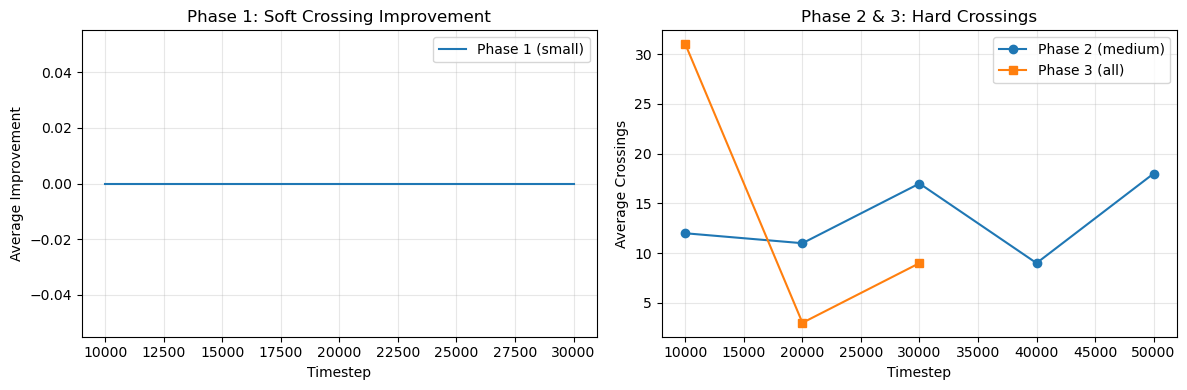

In [14]:
# Plot training history if available
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Phase 1 curve
if 'callback1' in locals() and callback1.history:
    steps = [h["step"] for h in callback1.history]
    improvements = [h["avg_imp"] for h in callback1.history]
    axes[0].plot(steps, improvements, label="Phase 1 (small)")
    axes[0].set_xlabel("Timestep")
    axes[0].set_ylabel("Average Improvement")
    axes[0].set_title("Phase 1: Soft Crossing Improvement")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

# Phase 2 & 3 combined
if 'callback2' in locals() and callback2.history:
    steps2 = [h["step"] for h in callback2.history]
    crosses2 = [h["avg_cross"] for h in callback2.history]
    axes[1].plot(steps2, crosses2, label="Phase 2 (medium)", marker="o")

if 'callback3' in locals() and callback3.history:
    steps3 = [h["step"] for h in callback3.history]
    crosses3 = [h["avg_cross"] for h in callback3.history]
    axes[1].plot(steps3, crosses3, label="Phase 3 (all)", marker="s")
    axes[1].set_xlabel("Timestep")
    axes[1].set_ylabel("Average Crossings")
    axes[1].set_title("Phase 2 & 3: Hard Crossings")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=100)
print(f"Training curves saved to {OUTPUT_DIR}/training_curves.png")
plt.show()

## Section 13: Submission — .coord Export, Overlap Fix & Baseline Comparisons

Teacher requirements:
1. Submit gzipped tar of `.coord` files for test graphs (10000–10100)
2. Each `.coord` file has one line per node: `x y`
3. If any nodes overlap → that graph gets 50% worse crossing than neato baseline
4. Compare against baselines: neato, sfdp, SmartGD, SA, RL-MLP, GNN-RL

In [15]:
import tarfile
import sys

def fix_node_overlaps(coords, min_dist=1e-4):
    coords = coords.copy()
    n = coords.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < min_dist:
                angle = np.random.uniform(0, 2 * np.pi)
                nudge = np.array([np.cos(angle), np.sin(angle)]) * min_dist
                coords[j] += nudge
    return coords

def has_overlapping_nodes(coords, min_dist=1e-4):
    n = coords.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < min_dist:
                return True
    return False

def compute_baseline_crossings(G, method="neato"):
    G_int = nx.convert_node_labels_to_integers(G, ordering="sorted")
    try:
        if method in ("neato", "sfdp"):
            pos = nx.nx_agraph.graphviz_layout(G_int, prog=method)
        else:
            pos = nx.spring_layout(G_int, seed=42)
    except Exception:
        pos = nx.spring_layout(G_int, seed=42)
    coords = np.array([[pos[v][0], pos[v][1]] for v in G_int.nodes()], dtype=np.float32)
    xing = XingLoss(G_int, soft=False)
    with torch.no_grad():
        return int(xing(torch.tensor(coords)).item()), coords

print("=" * 80, flush=True)
print("SUBMISSION: Evaluating test graphs 10000-10100 (v3 FAST)", flush=True)
print("=" * 80, flush=True)

COORD_DIR = os.path.join(OUTPUT_DIR, "coord_files")
os.makedirs(COORD_DIR, exist_ok=True)

test_paths = get_test_paths_fast(ROME_DIR, min_idx=10000, max_idx=10100)
print(f"Test graphs found: {len(test_paths)}", flush=True)

full_results = []
t0_sub = time.time()

for idx, gpath in enumerate(test_paths):
    t_graph = time.time()
    gname = os.path.basename(gpath).replace(".graphml", "")
    G_raw = nx.read_graphml(gpath)
    G = nx.convert_node_labels_to_integers(G_raw, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    if n_nodes > MAX_NODES:
        print(f"  [{idx+1}] {gname}: SKIP ({n_nodes} nodes > {MAX_NODES})", flush=True)
        continue

    # ── Neato baseline ──
    neato_xings, neato_coords = compute_baseline_crossings(G_raw, "neato")

    # ── sfdp baseline ──
    sfdp_xings, _ = compute_baseline_crossings(G_raw, "sfdp")

    # v3: SKIP SA baseline (saves ~30s per graph, not needed for submission)

    # ── Our method: GD2 + refinement (fewer starts) ──
    best_our_crossings = float('inf')
    best_our_coords = None

    # v3: only 2 starting layouts (neato + 1 spring)
    starting_layouts = [neato_coords.copy()]
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=1)
    c = np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)
    c = (c - c.min(axis=0)) / (c.max(axis=0) - c.min(axis=0) + 1e-8)
    starting_layouts.append(c)

    for coords_init in starting_layouts:
        # v3: only 1 sharpness value
        gd_coords, gd_xings = gd2_optimize(G, coords_init, n_iters=150, lr=0.05, sharpness=15.0)
        if gd_xings < best_our_crossings:
            best_our_crossings = gd_xings
            best_our_coords = gd_coords.copy()
        if best_our_crossings == 0:
            break

    # Multi-strategy refinement (only if crossings remain)
    if best_our_coords is not None and best_our_crossings > 0:
        refined_coords, refined_xings = multi_strategy_refinement(G, best_our_coords, verbose=False)
        if refined_xings < best_our_crossings:
            best_our_crossings = refined_xings
            best_our_coords = refined_coords.copy()

    # ── Fix overlaps ──
    if best_our_coords is not None:
        best_our_coords = fix_node_overlaps(best_our_coords)
        assert not has_overlapping_nodes(best_our_coords), f"Overlap still exists in {gname}!"

        xing_check = XingLoss(G, soft=False)
        with torch.no_grad():
            best_our_crossings = int(xing_check(torch.tensor(best_our_coords)).item())

        coord_path = os.path.join(COORD_DIR, f"{gname}.coord")
        with open(coord_path, "w") as f:
            for i in range(n_nodes):
                f.write(f"{best_our_coords[i, 0]:.6f} {best_our_coords[i, 1]:.6f}\n")

    result = {
        "graph": gname,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "neato_crossings": neato_xings,
        "sfdp_crossings": sfdp_xings,
        "best_crossings": best_our_crossings,
    }
    full_results.append(result)

    elapsed = time.time() - t_graph
    print(f"  [{idx+1}/{len(test_paths)}] {gname}: ours={best_our_crossings} neato={neato_xings} sfdp={sfdp_xings} ({elapsed:.1f}s)", flush=True)

total_sub_time = time.time() - t0_sub
print(f"\nDone. {len(full_results)} graphs in {total_sub_time:.0f}s ({total_sub_time/60:.1f} min).", flush=True)


SUBMISSION: Evaluating test graphs 10000-10100 (v3 FAST)
Test graphs found: 99
  [1/99] grafo10000.38: ours=8 neato=11 sfdp=9 (0.9s)
  [2/99] grafo10001.32: ours=0 neato=0 sfdp=1 (0.3s)
  [3/99] grafo10002.40: ours=4 neato=4 sfdp=3 (0.9s)
  [4/99] grafo10003.40: ours=7 neato=13 sfdp=10 (0.9s)
  [5/99] grafo10004.32: ours=4 neato=4 sfdp=4 (0.8s)
  [6/99] grafo10005.39: ours=11 neato=23 sfdp=15 (0.9s)
  [7/99] grafo10006.98: ours=103 neato=125 sfdp=98 (3.5s)
  [8/99] grafo10007.31: ours=2 neato=2 sfdp=1 (0.8s)
  [9/99] grafo10008.42: ours=10 neato=39 sfdp=24 (2.0s)
  [10/99] grafo10009.31: ours=2 neato=2 sfdp=4 (0.8s)
  [11/99] grafo10010.39: ours=12 neato=12 sfdp=12 (0.9s)
  [12/99] grafo10011.31: ours=1 neato=1 sfdp=1 (0.8s)
  [13/99] grafo10012.40: ours=7 neato=13 sfdp=12 (1.1s)
  [14/99] grafo10013.31: ours=1 neato=1 sfdp=1 (0.9s)
  [15/99] grafo10014.39: ours=7 neato=16 sfdp=15 (1.0s)
  [16/99] grafo10015.39: ours=2 neato=3 sfdp=2 (0.9s)
  [17/99] grafo10016.39: ours=16 neato=19 sfd

## Section 14: SPC Summary, Baseline Comparison & tar.gz Packaging

SPC RESULTS (vs Neato baseline)
  Method                       SPC (%)
  ------------------------- ----------
  Neato (baseline)                0.00
  sfdp                           -0.79
  SmartGD (teacher ref)         -25.00
  RL-MLP (teacher ref)          -17.00
  GNN-RL (teacher ref)          -44.00
  Combo C v3 (ours)             -18.60
  ------------------------- ----------

  Total test graphs: 99
  Our avg crossings:   23.6
  Neato avg crossings: 29.1
  Graphs where ours < neato: 66/99
  Graphs with 0 crossings:   4/99

  Submission: ./results_combo_cv3/combo_cv3_submission.tar.gz
  Files in archive: 99
  Chart saved.


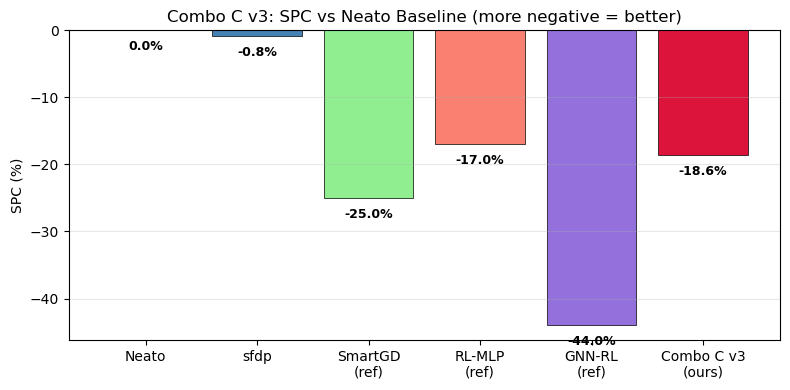

In [16]:
def compute_spc_for_method(full_results, method_key):
    vals = []
    for r in full_results:
        Di = r[method_key]
        Gi = r["neato_crossings"]
        denom = max(Di, Gi)
        if denom > 0:
            vals.append((Di - Gi) / denom)
        else:
            vals.append(0.0)
    return 100.0 * np.mean(vals)

spc_ours = compute_spc_for_method(full_results, "best_crossings")
spc_sfdp = compute_spc_for_method(full_results, "sfdp_crossings")

print("=" * 80, flush=True)
print("SPC RESULTS (vs Neato baseline)", flush=True)
print("=" * 80, flush=True)
print(f"  {'Method':<25} {'SPC (%)':>10}", flush=True)
print(f"  {'-'*25} {'-'*10}", flush=True)
print(f"  {'Neato (baseline)':<25} {'0.00':>10}", flush=True)
print(f"  {'sfdp':<25} {spc_sfdp:>10.2f}", flush=True)
print(f"  {'SmartGD (teacher ref)':<25} {'-25.00':>10}", flush=True)
print(f"  {'RL-MLP (teacher ref)':<25} {'-17.00':>10}", flush=True)
print(f"  {'GNN-RL (teacher ref)':<25} {'-44.00':>10}", flush=True)
print(f"  {'Combo C v3 (ours)':<25} {spc_ours:>10.2f}", flush=True)
print(f"  {'-'*25} {'-'*10}", flush=True)

our_crossings = [r["best_crossings"] for r in full_results]
neato_crossings = [r["neato_crossings"] for r in full_results]
print(f"\n  Total test graphs: {len(full_results)}", flush=True)
print(f"  Our avg crossings:   {np.mean(our_crossings):.1f}", flush=True)
print(f"  Neato avg crossings: {np.mean(neato_crossings):.1f}", flush=True)
print(f"  Graphs where ours < neato: {sum(1 for o, n in zip(our_crossings, neato_crossings) if o < n)}/{len(full_results)}", flush=True)
print(f"  Graphs with 0 crossings:   {sum(1 for o in our_crossings if o == 0)}/{len(full_results)}", flush=True)

tar_path = os.path.join(OUTPUT_DIR, "combo_cv3_submission.tar.gz")
with tarfile.open(tar_path, "w:gz") as tar:
    for r in full_results:
        coord_file = os.path.join(COORD_DIR, f"{r['graph']}.coord")
        if os.path.exists(coord_file):
            tar.add(coord_file, arcname=f"{r['graph']}.coord")

print(f"\n  Submission: {tar_path}", flush=True)
print(f"  Files in archive: {len(full_results)}", flush=True)

fig, ax = plt.subplots(figsize=(8, 4))
methods = ["Neato", "sfdp", "SmartGD\n(ref)", "RL-MLP\n(ref)", "GNN-RL\n(ref)", "Combo C v3\n(ours)"]
spcs = [0.0, spc_sfdp, -25.0, -17.0, -44.0, spc_ours]
colors = ["gray", "steelblue", "lightgreen", "salmon", "mediumpurple", "crimson"]
bars = ax.bar(methods, spcs, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("SPC (%)")
ax.set_title("Combo C v3: SPC vs Neato Baseline (more negative = better)")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, spcs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f"{val:.1f}%", ha="center", va="top", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "combo_cv3_spc_comparison.png"), dpi=150)
print(f"  Chart saved.", flush=True)
plt.show()
